<a href="https://colab.research.google.com/github/AisyahFadhillah/Pemodelan-Simulasi-dan-Optimasi/blob/main/simulasi_random_variabels_241061013_Aisyah_Fadhillah_Muhammad_Azis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
##Nama: Aisyah Fadhillah Muhammad Azis
##NIM: 241061013
##Mata Kuliah: Pemodelan Simulasi & Optimasi
##**Simulation 1: Generating Random Variabels**
---

**Instruksi Tugas (Tugas 3)**

Harga saham perusahaan X mengikuti pola return harian yang berdistribusi normal dengan:

Rata-rata return harian: 0.001 (0.1%)

Standar deviasi return harian: 0.02 (2%)

Harga awal saham: 100 unit mata uang

1. Gunakan distribusi normal untuk mensimulasikan harga saham selama 90 hari perdagangan.
2. Visualisasikan hasil simulasi dalam plot pergerakan harga saham.
3. Analisis bagaimana volatilitas harga saham yang diamati dalam hasil simulasi?

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [9]:
#Parameter
mu = 0.001          # Mean return harian
sigma = 0.02        # Standar deviasi return
days = 90           # Durasi simulasi
initial_price = 100 # Harga awal

In [10]:
# Set seed agar hasil bisa direplikasi
np.random.seed(42)

In [11]:
# Generate return harian dari distribusi normal
returns = np.random.normal(mu, sigma, days)
returns

array([ 0.01093428, -0.00176529,  0.01395377,  0.0314606 , -0.00368307,
       -0.00368274,  0.03258426,  0.01634869, -0.00838949,  0.0118512 ,
       -0.00826835, -0.0083146 ,  0.00583925, -0.0372656 , -0.03349836,
       -0.01024575, -0.01925662,  0.00728495, -0.01716048, -0.02724607,
        0.03031298, -0.00351553,  0.00235056, -0.02749496, -0.00988765,
        0.00321845, -0.02201987,  0.00851396, -0.01101277, -0.00483387,
       -0.01103413,  0.03804556,  0.00073006, -0.02015422,  0.0174509 ,
       -0.02341687,  0.00517727, -0.0381934 , -0.02556372,  0.00493722,
        0.01576933,  0.00442737, -0.00131297, -0.00502207, -0.02857044,
       -0.01339688, -0.00821278,  0.02214244,  0.00787237, -0.0342608 ,
        0.00748168, -0.00670165, -0.01253844,  0.01323353,  0.02161999,
        0.0196256 , -0.01578435, -0.00518425,  0.00762527,  0.0205109 ,
       -0.00858348, -0.00271318, -0.0211267 , -0.02292413,  0.01725052,
        0.0281248 , -0.0004402 ,  0.02107066,  0.00823272, -0.01

In [12]:
#Simulasi Harga
prices = np.zeros(days)
prices[0] = initial_price
for t in range(1, days):
    prices[t] = prices[t-1] * (1 + returns[t])
prices

array([100.        ,  99.8234714 , 101.21638523, 104.40071315,
       104.01619828, 103.63313376, 107.00994235, 108.75941521,
       107.84697943, 109.12509565, 108.22281075, 107.3229819 ,
       107.94966713, 103.92685748, 100.44547855,  99.41633923,
        97.50191632,  98.21221258,  96.52684372,  93.89686619,
        96.74315959,  96.40305649,  96.62965805,  93.97282911,
        93.04365825,  93.34311477,  91.28771138,  92.06493133,
        91.05104107,  90.61091172,  89.61109894,  93.02040371,
        93.08831377,  91.21219154,  92.80392622,  90.63074846,
        91.09996849,  87.62055073,  85.38064342,  85.80218684,
        87.15522998,  87.54109805,  87.42615959,  86.98709896,
        84.50183928,  83.36977793,  82.68508067,  84.51593048,
        85.1812708 ,  82.26289205,  82.87835663,  82.32293526,
        81.29073407,  82.3664971 ,  84.14725998,  85.79870065,
        84.44442389,  84.00664309,  84.64721631,  86.38340711,
        85.64193646,  85.40957451,  83.60515209,  81.68

In [13]:
#Membuat dataframe
df = pd.DataFrame({
    'Hari': np.arange(days),
    'Harga': prices,
    'Return': returns
})

print(df)

    Hari       Harga    Return
0      0  100.000000  0.010934
1      1   99.823471 -0.001765
2      2  101.216385  0.013954
3      3  104.400713  0.031461
4      4  104.016198 -0.003683
..   ...         ...       ...
85    85   86.707023 -0.009035
86    86   88.381166  0.019308
87    87   89.050656  0.007575
88    88   88.196196 -0.009595
89    89   89.189757  0.011265

[90 rows x 3 columns]


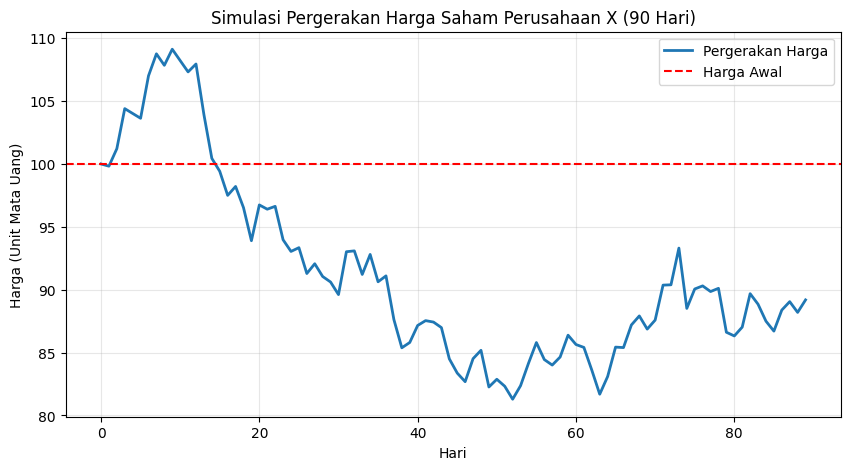

In [14]:
#Visualisasi hasil simulasi
plt.figure(figsize=(10, 5))
plt.plot(df['Hari'], df['Harga'], label='Pergerakan Harga', color='tab:blue', linewidth=2)
plt.axhline(y=initial_price, color='red', linestyle='--', label='Harga Awal')
plt.title("Simulasi Pergerakan Harga Saham Perusahaan X (90 Hari)")
plt.xlabel("Hari")
plt.ylabel("Harga (Unit Mata Uang)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Grafik simulasi di atas menunjukkan bahwa harga saham Perusahaan X cenderung mengalami tren penurunan setelah sempat melonjak di awal periode. Meskipun sempat mencapai puncak di atas 100 unit mata uang pada dua minggu pertama, harga kemudian terkoreksi tajam dan bergerak fluktuatif di bawah nilai awal, dengan titik terendah berada di kisaran 81–82 unit mata uang sebelum akhirnya ditutup pada level yang jauh lebih rendah dibanding harga pembukaannya.

In [15]:
# Estimasi Tre Harga Menggunakan Metode OLS
X = sm.add_constant(df['Hari']) # Menambahkan konstanta
model = sm.OLS(df['Harga'], X).fit()

print("--- RINGKASAN ANALISIS STATISTIK ---")
print(model.summary())

--- RINGKASAN ANALISIS STATISTIK ---
                            OLS Regression Results                            
Dep. Variable:                  Harga   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     98.17
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           5.55e-16
Time:                        15:22:17   Log-Likelihood:                -273.70
No. Observations:                  90   AIC:                             551.4
Df Residuals:                      88   BIC:                             556.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        10